In [156]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import math
import matplotlib.pyplot as plt
import numpy as np

In [9]:
# for downloading the dataset
!curl -o input.txt https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
with open('input.txt', 'r') as f:
    text = f.read()

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 1089k  100 1089k    0     0  7946k      0 --:--:-- --:--:-- --:--:-- 7950k


In [10]:
#total number of characters in text
len(text) 


1115394

In [11]:
# first 1000 characters
print(text[:1000])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods know I
speak this in hunger for bread, not in thirst for revenge.



In [12]:
chars = sorted(list(set(text)))
vocab_size = len(chars)
print("|".join(chars))
print(vocab_size)
chars[0], chars[1]


| |!|$|&|'|,|-|.|3|:|;|?|A|B|C|D|E|F|G|H|I|J|K|L|M|N|O|P|Q|R|S|T|U|V|W|X|Y|Z|a|b|c|d|e|f|g|h|i|j|k|l|m|n|o|p|q|r|s|t|u|v|w|x|y|z
65


('\n', ' ')

- `set()` creates a collection of all unique characters in the dataset.
- `sorted()` arranges these unique characters in ascending order.
- **Note:** the first character is a newline (`'\n'`), and the second is a space (`' '`). Both are treated as unique characters.

In [21]:
# string to integer --> dictionary of mapping from string to integer
s_to_i = { ch:i for i,ch in enumerate(chars)} 

# integer to string --> dictionary of mapping from integer to string
i_to_s = { i:ch for i,ch in enumerate(chars)}

# lambda creates a simple function in python which takes s/l as input
encode = lambda s: [s_to_i[c] for c in s]
decode = lambda l: ''.join([i_to_s[i] for i in l])      #creates list of characters then join them with null spaces

print(encode("b"))
print(decode(encode("astha-paddta")))
(decode([0,59])) , (decode([1]))

[40]
astha-paddta


('\nu', ' ')

# why subwords instead of words or characters
| Aspect | Character-level | Subword-level | Word-level |
|--------|----------------|---------------|------------|
| **Explanation** | - At the character level, the model has to learn to form subwords, then words, and finally sentences.  <br> - This is a harder task and requires significantly more training time. <br> - Even short sentences turn into very long token sequences, making harder for model to learn character that are very far away. <br> - Because LLMs generate outputs autoregressively (predicting one token at a time), more tokens mean longer prediction times and less efficiency. | - Subwords lie between character-level and word-level tokenization. <br> - With characters: tokens are very short, but vocabulary is tiny. <br> - With words: tokens are long, but vocabulary size explodes. <br> - Subwords strike a balance: a manageable vocabulary size with tokens that carry more semantic meaning than characters. | - A purely word-based vocabulary would be extremely large, making training infeasible. <br> - For example, instead of teaching the model separate tokens for *playing*, *played*, *plays*, it’s more efficient to break them into a base word + suffix (e.g., *play* + `ing`, `ed`, `s`). <br> - This way, the model can generalize across word forms, just like humans learn language — recognizing common roots and affixes. <br> - In practice, frequent words often remain whole tokens, while less common words are split into subwords, keeping the vocabulary compact while preserving richness. |


In [14]:
# data is the collection of tokens
data = torch.tensor(encode(text),dtype=torch.long)
print(data.shape, data.dtype)
data[:1000]

torch.Size([1115394]) torch.int64


tensor([18, 47, 56, 57, 58,  1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 14, 43, 44,
        53, 56, 43,  1, 61, 43,  1, 54, 56, 53, 41, 43, 43, 42,  1, 39, 52, 63,
         1, 44, 59, 56, 58, 46, 43, 56,  6,  1, 46, 43, 39, 56,  1, 51, 43,  1,
        57, 54, 43, 39, 49,  8,  0,  0, 13, 50, 50, 10,  0, 31, 54, 43, 39, 49,
         6,  1, 57, 54, 43, 39, 49,  8,  0,  0, 18, 47, 56, 57, 58,  1, 15, 47,
        58, 47, 64, 43, 52, 10,  0, 37, 53, 59,  1, 39, 56, 43,  1, 39, 50, 50,
         1, 56, 43, 57, 53, 50, 60, 43, 42,  1, 56, 39, 58, 46, 43, 56,  1, 58,
        53,  1, 42, 47, 43,  1, 58, 46, 39, 52,  1, 58, 53,  1, 44, 39, 51, 47,
        57, 46, 12,  0,  0, 13, 50, 50, 10,  0, 30, 43, 57, 53, 50, 60, 43, 42,
         8,  1, 56, 43, 57, 53, 50, 60, 43, 42,  8,  0,  0, 18, 47, 56, 57, 58,
         1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 18, 47, 56, 57, 58,  6,  1, 63,
        53, 59,  1, 49, 52, 53, 61,  1, 15, 39, 47, 59, 57,  1, 25, 39, 56, 41,
        47, 59, 57,  1, 47, 57,  1, 41, 

In [15]:
# splitting into training and validation set(90% training , 10% validation)
n = int(0.9*len(data))
train = data[:n]
valid= data[n:]


In [16]:
context_len= 8
train[:context_len+1] 

tensor([18, 47, 56, 57, 58,  1, 15, 47, 58])

- Context length is the maximum number of tokens over which the model can learn and capture dependencies
- +1 because we are making 8 predictions(the last prediction would be using all the 8 context length)

In [17]:
for i in range(1,context_len+1):
    x = train[:i]
    y = train[i]
    print(x ,y)

tensor([18]) tensor(47)
tensor([18, 47]) tensor(56)
tensor([18, 47, 56]) tensor(57)
tensor([18, 47, 56, 57]) tensor(58)
tensor([18, 47, 56, 57, 58]) tensor(1)
tensor([18, 47, 56, 57, 58,  1]) tensor(15)
tensor([18, 47, 56, 57, 58,  1, 15]) tensor(47)
tensor([18, 47, 56, 57, 58,  1, 15, 47]) tensor(58)


- During training, the transformer is exposed to as little to maximum length of context. This helps it learn to make good predictions even when only a little context is available at inference time.

In [79]:
torch.manual_seed(2)
batch_size = 4
context_len= 8

def get_batch(split):
    data = train if split == "train" else valid
    i_x = torch.randint(len((data)-context_len),(batch_size,)) 
    x = torch.stack([data[i : i + context_len] for i in i_x])
    y = torch.stack([data[i+1:i+context_len+1] for i in i_x])
    return x,y

xb, yb = get_batch('train')  
xb.shape , yb.shape     #(xb , yb) --> (batch_size , time_step)


(torch.Size([4, 8]), torch.Size([4, 8]))

- **`randint`** → Used for generating random integers with a given shape.  
  - It takes two arguments:  
    1. The upper limit (number up to which we want to generate).  
    2. The shape of the output.  

- **Subtracting `context_len`** → We do this because the last set is incomplete:  
  - For the last element of the last set, we don’t have any tokens that come after it.  

-  Why are we randomly sampling vectors from any part of the sentence? If we took batches sequentially, the model would be learning the complete flow of the text and have much better understanding of the text?

    - It’s like taking tiny steps in the loss landscape. At first glance, expecting small, similar changes in the gradient might sound good, but it actually **prevents the model from exploring the entire loss landscape (exploitation)**. It also **slows down convergence**, because the model doesn’t get a broader view of the full loss landscape and therefore has a harder time finding the optimal solution.

 


In [54]:
a = nn.Embedding(5 , 6)
print(a.weight.min().item(), a.weight.max().item())
b = torch.zeros((2,3), dtype=torch.long)
print(b)
a(b) , a(b).shape

-1.4648686647415161 2.391206979751587
tensor([[0, 0, 0],
        [0, 0, 0]])


(tensor([[[ 0.6888,  0.0453, -1.4162,  0.8670, -0.3963,  1.3569],
          [ 0.6888,  0.0453, -1.4162,  0.8670, -0.3963,  1.3569],
          [ 0.6888,  0.0453, -1.4162,  0.8670, -0.3963,  1.3569]],
 
         [[ 0.6888,  0.0453, -1.4162,  0.8670, -0.3963,  1.3569],
          [ 0.6888,  0.0453, -1.4162,  0.8670, -0.3963,  1.3569],
          [ 0.6888,  0.0453, -1.4162,  0.8670, -0.3963,  1.3569]]],
        grad_fn=<EmbeddingBackward0>),
 torch.Size([2, 3, 6]))

- nn.Embedding projection of 5 random character to 6 dimension , i.e. each character is represented into a 6 dimensional Space with random parameters, with range of parameters between -1/6 , +1/6 (here).
- b could be seen as a seed which would start the generation process, since each element of the b is same the projections are same too

In [ ]:
torch.manual_seed(1337)
class BigranLanguageModel(nn.Module):
    def __init__(self,vocab_size):
        super().__init__()
         
        self.token_embedding_table = nn.Embedding(vocab_size, vocab_size)       #initial embedding range in pytorch is -1/vocan_size to 1/vocab_size(these are not probability yet)

    # idx and targets are both (Batch , Tokens)
    def forward(self, idx, targets=None):  
        
        logits = self.token_embedding_table(idx) 
        if targets is None:
            loss = None
        
        else:
            B,T,C = logits.shape
            logits = logits.view(B*T,C)     #given the current token the probability corresponding to entire vocabulary
            targets = targets.view(B*T)         # 
            loss = F.cross_entropy(logits,targets)      #predictin corresponding to each class 
        
        return logits  , loss   #(batch_size, time_step , channel)
    
    def generate(self,idx,max_new_tokens):
        for _ in range(max_new_tokens):
            logits, loss = self(idx)   #here forward is called without given targets, hence we only get projection of the input tokens
            logits = logits[:,-1,:] 
            probs = F.softmax(logits, dim = -1)
            idx_next = torch.multinomial(probs, num_samples=1) #4 * 1
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

m = BigranLanguageModel(vocab_size)
print(decode(m.generate(idx= torch.zeros((1,1), dtype = torch.long), max_new_tokens= 10)[0].tolist()))
_ , loss = m(idx= torch.zeros((1,1), dtype = torch.long), targets = torch.zeros((1,1), dtype = torch.long))
print(loss.item()) , print(-math.log(1/65))



SKIcLT;AcE
4.70305061340332
4.174387269895637


(None, None)

- the word logit is itself quite misleading because these are not in the range 0 to 1 until they are passed into cross_entropy loss
- also logits = self.token_embedding_table(idx) not to be confused with the embedding corresponding to the current token but rather distribution of the prediction token
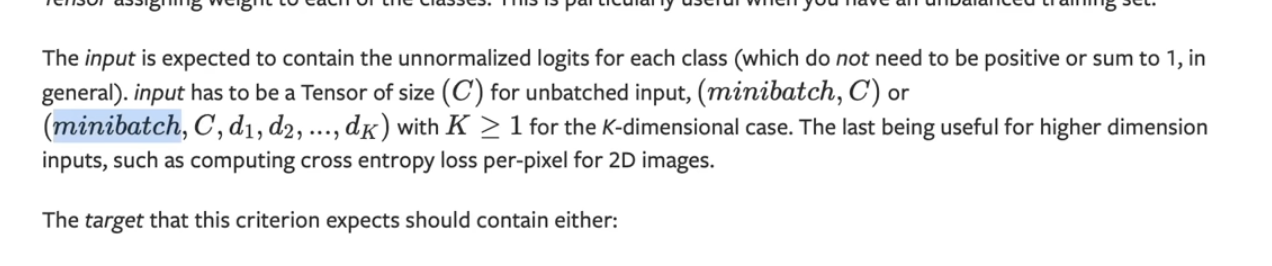
- pytorch expected the input in torch.nn.crossentropyloss to be in (batch* time_step , channels)


- if we compare it with the -log(1/65), we can see the model is even performing worse than the random guessing now
-     logits = logits[:,-1,:]  we have taken only the probabilities corresponding to the last time step because this is the bigram model next token is based only on previous token , if we change the from -1 to -n , we would be having a (n+1) gram model , the general formula of context lenght and gram model is  n gram model = context_len - 1

In [75]:
optimizer = torch.optim.Adam(m.parameters(), lr = 1e-3)

In [ ]:
batch_size = 32
for steps in range(1000):
    xb , yb = get_batch("train")

    logits , loss = m(xb , yb)
    optimizer.zero_grad(set_to_none=True)   #set_to_none is more
    loss.backward()
    optimizer.step()

print(loss.item())

2.413191080093384


In [82]:
print(decode(m.generate(idx= torch.zeros((1,1), dtype = torch.long), max_new_tokens= 1000)[0].tolist()))



HAs th.
OR:
WAstlor cit on que, Yownt hee rintared Pe;; win, PHoine myouacet sathy ca thange RIOKI fe welitus ANCOLIUCKIO:
D:
Wh be r wo by benrto angowhe y coulpe nghell sove thy noul is
ABYOUSeay mace lequ otw hendy.


BRourat pals, haley ind ses.
Thaninsthinethisthe maboveistoukictlatin t co,
Any hand isally s.
Tin
ARENRAMPSThe that hint ad by nche KI dy Wheysu d:
FOfin?
P Ornisothay,



DUCO:
Bur!
Aw misly ther pro dort Pllis.
G ge cor she'siocen s atru k!
Ans.
CEDiarcouthariman ives w-d, ffrdd, my

Asinceswhon K:
QUSe!
Tand, toroand t,
NGRD y we wheanopo fous for deassee t, elonde ourefof hibafayo e t than's bue: tharngea s Tatsowo antiert oo kigou mppe I winiore thane, Wheayool m t phthikerortet llomencet cod 'spo f ir seto fthown,

OLO, o y hay INThee?
beandou:
Vounintice gr, t the irs!
le:
Mas, d s athans.

OROratoucour have:
CHe thtend Comard athey omofin mitite t pRK:
Wowh hon t g cherid for ware m wos y to thad mid mo he?
AS: mbaullo Ouce thoninoougry nun RO:


LOrs t ofal

# maths behind attention

- in the above bigram model we see that the input when passed to the forward pass projects into the distriubutin of the future token , but in all the below example the embedding are of the current tokens,(in reality too the embedding are first projected into the current tokens , only when we apply feed forward layer and softmax the distributin is made to shift towards the future token predictions), untill attention we are only working with the projection of the current tokens not probabilty of th efuture distribution


In [ ]:
# version 1
torch.manual_seed(1337)
batch , time , channel = 4,8,2
x = torch.randn(batch,time,channel)      #random number from normal distribution(rand(n))
x_bow1= x_bagofwords = torch.zeros((batch,time,channel))

for b in range(batch):
    for t in range(time):
        xpre= x[b,:t+1]     #:t+1 is number not index
        x_bagofwords[b,t]= torch.mean(xpre,dim=0)   #mean across column
(x_bow1[0]   , x[0])


(tensor([[ 0.1808, -0.0700],
         [-0.0894, -0.4926],
         [ 0.1490, -0.3199],
         [ 0.3504, -0.2238],
         [ 0.3525,  0.0545],
         [ 0.0688, -0.0396],
         [ 0.0927, -0.0682],
         [-0.0341,  0.1332]]),
 tensor([[ 0.1808, -0.0700],
         [-0.3596, -0.9152],
         [ 0.6258,  0.0255],
         [ 0.9545,  0.0643],
         [ 0.3612,  1.1679],
         [-1.3499, -0.5102],
         [ 0.2360, -0.2398],
         [-0.9211,  1.5433]]))

# Intuition Behind Averaging

Let's say we have:  
- **Batch size** = 1  
- **Context length** = 4  
- **Channel dimension** = 8 (corresponding to some probabilities for words, not literal)  

Consider the sequence: `["astha", "is", "eating", "pasta"]`.

for x
### Time step 0
The model has only seen the word `"astha"` and projects an 8-dimensional vector representing probabilities for the next word.

### Time step 1
similary the model sees the next word `"is"`, and projects probabilities for the next word similarly.

### Time step t
Now we want some sort of metric that represnts all the values(tokens) that the model has seen so far, and we know what a better metric than average for this so When we take the average of the embeddings up to time step t, each channel value represents a **soft summary of all words seen so far**. It does **not preserve the exact order of words**, but gives a **vague probability distribution over the words/features that have appeared**. for instamce at time t = 0 

Hence, averaging produces a **bag-of-words style representation** that summarizes everything seen up to the current time step.

- If we think now, this is the primary reason of taking positional embedding in the attention mechanism.


In [ ]:
#version 2
torch.manual_seed(1337)
batch , time , channel = 4,8,2
x = torch.randn(batch,time,channel)     
c = torch.zeros(batch, time, channel)
a = (torch.tril(torch.ones(8,8)))       #lower triangular matrix
a = a/a.sum(dim=1, keepdim=True)
print(a)
x_bow2 = a @ x  
x_bow2[0]

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3333, 0.3333, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2500, 0.2500, 0.2500, 0.2500, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2000, 0.2000, 0.2000, 0.2000, 0.2000, 0.0000, 0.0000, 0.0000],
        [0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.0000, 0.0000],
        [0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.0000],
        [0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250]])


tensor([[ 0.1808, -0.0700],
        [-0.0894, -0.4926],
        [ 0.1490, -0.3199],
        [ 0.3504, -0.2238],
        [ 0.3525,  0.0545],
        [ 0.0688, -0.0396],
        [ 0.0927, -0.0682],
        [-0.0341,  0.1332]])

In [98]:
torch.allclose(x_bow1,x_bow2)      #these are same proved

True

In [ ]:
# version 3
# using softmax
tril = torch.tril(torch.ones(time, time))
wei = torch.zeros((time,time))
wei= wei.masked_fill(tril ==0, float("-inf"))   #filling with negative infinity wherever value of tril is zero
print(wei)
wei = F.softmax(wei, dim=-1)
print(wei)
x_bow3 = wei@ x
print(x_bow3[0])
torch.allclose(x_bow2, x_bow3)

tensor([[0., -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., 0., -inf, -inf, -inf],
        [0., 0., 0., 0., 0., 0., -inf, -inf],
        [0., 0., 0., 0., 0., 0., 0., -inf],
        [0., 0., 0., 0., 0., 0., 0., 0.]])
tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3333, 0.3333, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2500, 0.2500, 0.2500, 0.2500, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2000, 0.2000, 0.2000, 0.2000, 0.2000, 0.0000, 0.0000, 0.0000],
        [0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.0000, 0.0000],
        [0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.0000],
        [0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250]])
tensor([[ 0.18

True

- We can see how the basic idea of averaging motivates the powerful concept of attention. Intuitively, the main problem with averaging is that it gives equal importance to all embeddings up to time \(t\), which is unfair: some embeddings are important and some are not. There should be weights that indicate how important each token is (which is what attention computes).

- For example, as we move from time step 0 to time step 1, new information arrives. At time step 0 the model has only seen the word “astha,” so it gives full importance to that token. At time step 1 the model has seen “astha” and “is.” The question is: how much does the importance of the previous token change when we add this new information? In other words, how much does the new word influence the contribution of previous tokens? If the new token is highly relevant for some previous tokens, then the weights given to those previous tokens at that time step should be higher compared to other tokens.

- Attention captures this relevance between the current token (the query) and each previous token (the keys), typically with a dot product (saying two tokens are highly relevant is similar to saying the two tokens point in the same direction in vector space). For instance, in “astha is pasta,” “pasta” and “astha” imply similar meaning and so should point in the same direction.

- once we start using attention the model is not bigram anymore


In [ ]:
#version 4
torch.manual_seed(1337)
b , t , c = 4, 8 , 32
x = torch.randn((b,t,c))

#single head attention
head_size = 16
key = nn.Linear(c , head_size , bias = False)
query = nn.Linear(c , head_size , bias = False)
value = nn.Linear(c , head_size , bias = False)
k = key(x)     
q = query(x)     
v = value(x)
v.shape
wei = q @ k.transpose(-2,-1) 
tril = torch.tril(torch.ones(t,t))
wei= wei.masked_fill(tril ==0, float("-inf"))   #filling with negative infinity wherever trill value is 0 in wei ,cause we want present token to predict the future(not to see them) 
wei = F.softmax(wei, dim=-1)
out = wei @ v
print(out.shape)
wei[0],out[0] 

torch.Size([4, 8, 16])


(tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.1574, 0.8426, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.2088, 0.1646, 0.6266, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.5792, 0.1187, 0.1889, 0.1131, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.0294, 0.1052, 0.0469, 0.0276, 0.7909, 0.0000, 0.0000, 0.0000],
         [0.0176, 0.2689, 0.0215, 0.0089, 0.6812, 0.0019, 0.0000, 0.0000],
         [0.1691, 0.4066, 0.0438, 0.0416, 0.1048, 0.2012, 0.0329, 0.0000],
         [0.0210, 0.0843, 0.0555, 0.2297, 0.0573, 0.0709, 0.2423, 0.2391]],
        grad_fn=<SelectBackward0>),
 tensor([[-0.1571,  0.8801,  0.1615, -0.7824, -0.1429,  0.7468,  0.1007, -0.5239,
          -0.8873,  0.1907,  0.1762, -0.5943, -0.4812, -0.4860,  0.2862,  0.5710],
         [ 0.6764, -0.5477, -0.2478,  0.3143, -0.1280, -0.2952, -0.4296, -0.1089,
          -0.0493,  0.7268,  0.7130, -0.1164,  0.3266,  0.3431, -0.0710,  1.2716],
         [ 0.4823, -0.1069, -0.40

In [273]:
k = torch.randn(b , t , head_size)
q = torch.randn(b , t , head_size)
wei = q @ k.transpose(-2,-1)
k.var(), q.var() , wei.var(), 

(tensor(0.9006), tensor(1.0037), tensor(15.9317))

SyntaxError: invalid syntax (2512899117.py, line 2)

- so yes , all the steps in the modern tranformer , has some meaning an dintution behind it , these were not some random maniac who one day decided to start doing some random projections , i feel it would be injustice to give attention all the credit attention is what is the heart of the modern day transformer, but it is not what drives the complete transformer , to appreciate the beauty of transformer , we need to appreaciate all these steps individually and mathematically.
# the key idea behind attention is learning relations in the smaller dimension and then projecting it back to the larger dimension , but why do we do so, there must be some loss of inforamtion while doing do ?
- yes , there is mathematically loss of information when projectiing into the smaller dimension , but that is compensatied by using multiple heads , think of it as 3 d space , when you project the information, into the 2 d space yes there would be some loss of inforamtion , but instead of representing information in 1 2-D space , you could use two 2-d head or maybe 3, and recover most of the information , concat these and then project back into the original space , and this is what happens in multi head attention(so when we say multiple heads gives multiple perspective this is what we measn , they learn mutiple channels of the same data indendently)
- another importance technicality would be why are we again projecting from n_emb to n_embing again, all the heads lives in the same space but these space are not linked to each other in any way, analagous to above example , when we project , 3 d space into lets say 3 one dimensional spcae and concat them , so yes now our space is back to 3d agian , but still all these 1d space are behvaing like a unique identliy they know , have information about the state of the other space , so to combine these information again in one piece of information(which is again a technnique to reterive the lost information) , we do projection from n_emb to n_emb , to recover the information loss 
- still ,after all these projections , we can not guarantee there would be no loss , to recover the original identity of the information we add the original x as a residual network, to the output of the multihead head, so that these could be used by the later layers
- in ffn why do we project into a higher dimension, if we remenber correctly we have already projected in multi head from n_emb to n_meb, then why again so 
1 . the first reason is whaever the model have learnt un until now , is linear , it stil does not know to represent complex information yet.
2 . okay so we can directly apply it after projection in multihead , why projecting into higher dim to be more specific 4* n_emb dimension , applying relu their and then again back to n_emb , - short answer would be to it gives the model ability to learn more complex information , information in igher dimension are much more richer, and applying relu their would give model better chance to learn non- linear information better than in smaller dimension , think of it as a what would be is more complex non linera function relu in 1 d (1 and 0 ) in 1 d or relu in 4/n d([1,0,0,1], [0,0,1,0], etc etc)

- query : if we compare it with the howm uch weight should we give in the the attention mechnaism , we get a quite intuitive understandinf why is it called query, it's like asking how much this current token is relavent(correlated) to the tokens in the key(which is the key(what do i contain for you) answer of the query ), and then weighing them according to theier important using value matrix(how much value should be given to each token weighing by thier importance)
- self- attension --> becuase key, query and value are all coming from the same source that is x
- in cross attention - that's why query comes from the different source while the key and value comes from the same source.
- in decoder block --> we used maked attention(could be cross or self) which measn token upto time t can only communitacte with the past ,we don't want it to see the next token and hence mask it so it predict the answer in the autoregressive way
- in encoder block we let it talk to each other, all tokens can talk to each other , inthe original paper"attention is all you need" the goal was language translation , since in differertn language words with similar meaning can appear at any posiiton in time.(again in general encoder could have self or cross attention) depending upon the objective.



In [ ]:
x = torch.zeros((b,t,c))
head_size = 16
key = nn.Linear(c , head_size , bias = False)
query = nn.Linear(c , head_size , bias = False)
k = key(x)     
q = query(x)
k.shape

torch.Size([4, 8, 16])

- the problem with the softmax is even though everthing is scaled proportinally , the softmax distribution becomes too peaky as the difference between the weights increses, which we don't want ,hence divide it by number of dimension of query(doubt), during initization we dont want it to be too peaky , giving much higher weight , hence to tone it down we divide 
- if we see weights intuitively , it measn how much important a given toekn is if x1= 1,2 and x2 = 2,4 it will be communication the same information the second token is twice as important as the first token, but the porblem wiht the softmax is it, if we apply softmax to this vector the x2 distribution would be much peaky as the difference between the values increases which we don't want during initialization hence to keep the scale same , divide it by the scale i.e. underoot of dk

In [ ]:
- why multiple head --> it help to get multiple communication channels, independentanetly , gather lot of data , learning different perspective of the data\

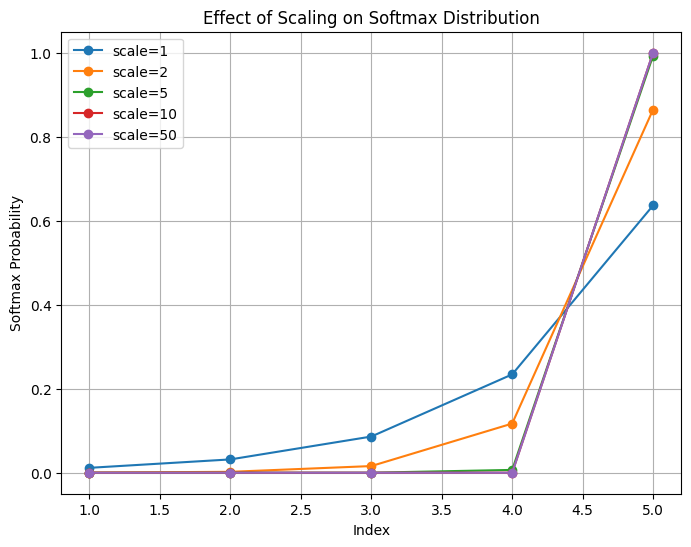

In [157]:
def softmax(x):
    e_x = np.exp(x - np.max(x))  # subtract max for numerical stability
    return e_x / e_x.sum()

# Base vector
x = np.array([1, 2, 3, 4, 5])

# Different scales
scales = [1, 2, 5, 10, 50]

plt.figure(figsize=(8, 6))

for scale in scales:
    scaled_x = x * scale
    sm = softmax(scaled_x)
    plt.plot(x, sm, marker='o', label=f"scale={scale}")

plt.title("Effect of Scaling on Softmax Distribution")
plt.xlabel("Index")
plt.ylabel("Softmax Probability")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# why do we care about normalization 

- we can see from the figure how scaling the weight even by 5 times , makes the distribution of softmax almost looking like a one hot encoding , this makes the training biased initially as the paramters corresponding to higher values are given a illusion of more important towards a particular channel by model , we don't want that , we want the model to give equal importance to every feature intially (the probabilty distribution after applying the softmax shoudd not be too picky it should be somewhat uniform becasue before training every features should be given ewqual impotance ), to over this scaling issue we applying scaling while training at different stages of the model , because relative importance of the weight does not change with the scale while the softmax changes too much , and so to make it scale invariate we do normalization 

- layer normzalization --> in transformer each layer corresponds to different entity following some multinomial distribution , to get , and we want all the entiry 
- batch normalization --> 
- instance normalization -->
- group normalization --> 